In [2]:
# importing libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [3]:
# Step 2: Load Feature Engineered Dataset
df = pd.read_csv("../data/processed/featured_data.csv")

df.head()

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Addiction_Risk,Usage_Sleep_Ratio,Wellbeing_Score,Conflict_Intensity,Academic_Risk
0,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8,High,0.800000,12.5,Low,1
1,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3,Low,0.280000,15.5,NaN,0
2,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9,High,1.200000,10.0,Medium,1
3,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4,Low,0.428571,14.0,Low,0
4,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7,Medium,0.750000,12.0,Low,1


In [4]:
# Step 3: Check Target Distribution
df["Addiction_Risk"].value_counts()  # this helps us understand whether the class are balanced

Addiction_Risk
Medium    406
High      199
Low       100
Name: count, dtype: int64

In [5]:
# Step 4: Encode Categorical Variables
# First identify categorical columns:
df.select_dtypes(include="object").columns

C:\Users\vedik\AppData\Local\Temp\ipykernel_8708\2564836762.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Relationship_Status', 'Addiction_Risk',
       'Conflict_Intensity'],
      dtype='str')

In [6]:
# Encode:
le = LabelEncoder()

for col in df.select_dtypes(include="object"):
    df[col] = le.fit_transform(df[col])

C:\Users\vedik\AppData\Local\Temp\ipykernel_8708\817261722.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [7]:
# Check:
df.head()

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Addiction_Risk,Usage_Sleep_Ratio,Wellbeing_Score,Conflict_Intensity,Academic_Risk
0,19,0,2,10,5.2,1,1,6.5,6,1,3,8,0,0.800000,12.5,0,1
1,22,1,0,39,2.1,7,0,7.5,8,2,0,3,1,0.280000,15.5,2,0
2,20,0,2,102,6.0,6,1,5.0,5,0,4,9,0,1.200000,10.0,1,1
3,18,1,1,101,3.0,11,0,7.0,7,2,1,4,1,0.428571,14.0,0,0
4,21,1,0,18,4.5,0,1,6.0,6,1,2,7,2,0.750000,12.0,0,1


In [8]:
# Step 5: Define Features and Target
X = df.drop(
    ["Addicted_Score", "Addiction_Risk"],
    axis=1
)

y = df["Addiction_Risk"]

In [9]:
# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
# Verify:
print(X_train.shape)
print(X_test.shape)

(564, 15)
(141, 15)


In [11]:
# Step 7: Logistic Regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

Accuracy: 0.9787234042553191


C:\Users\vedik\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
# Step 8: Decision Tree
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, dt_pred))

Accuracy: 0.9787234042553191


In [13]:
# Step 9: Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

Accuracy: 0.9858156028368794


In [14]:
# Step 10: Compare Models
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,Random Forest,0.985816
0,Logistic Regression,0.978723
1,Decision Tree,0.978723


In [15]:
# Step 11: Detailed Evaluation of Best Model
# Assume Random Forest wins:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      0.90      0.95        20
           2       0.98      1.00      0.99        81

    accuracy                           0.99       141
   macro avg       0.99      0.97      0.98       141
weighted avg       0.99      0.99      0.99       141



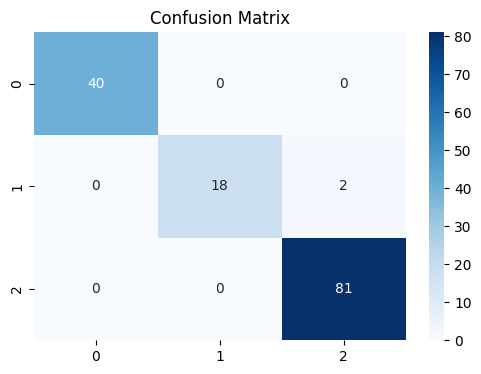

In [16]:
# Step 12: Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [17]:
# Step 13: Feature Importance (Very Important)
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
10,Conflicts_Over_Social_Media,0.189764
8,Mental_Health_Score,0.183766
13,Conflict_Intensity,0.168409
12,Wellbeing_Score,0.167535
11,Usage_Sleep_Ratio,0.093909
4,Avg_Daily_Usage_Hours,0.068740
7,Sleep_Hours_Per_Night,0.037873
3,Country,0.019560
5,Most_Used_Platform,0.016980
14,Academic_Risk,0.013804


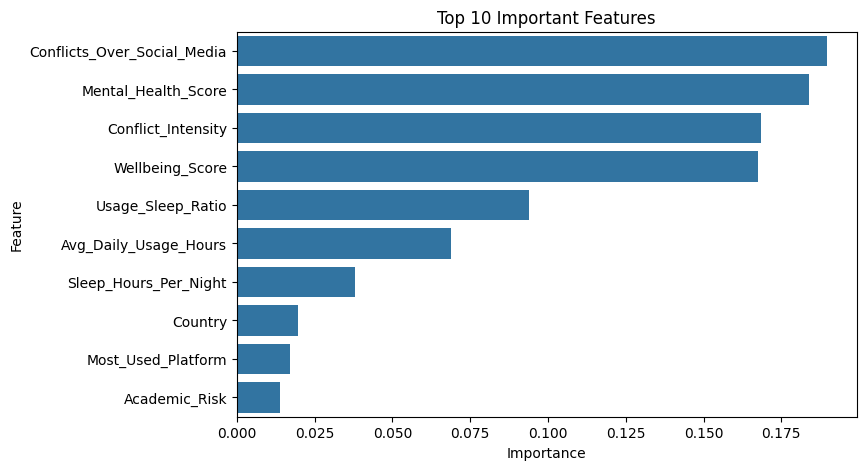

In [18]:
# Visualization:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

## Key Findings for Report
- Top Predictors of Addiction Risk
- Conflicts Over Social Media
- Mental Health Score
- Conflict Intensity
- Wellbeing Score
- Usage Sleep Ratio

## Business Insight
- Students experiencing frequent social-media-related conflicts and lower mental health scores are significantly more likely to fall into higher addiction risk categories.

- Sleep quality and daily usage behavior also play a critical role in determining addiction risk.

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      0.90      0.95        20
           2       0.98      1.00      0.99        81

    accuracy                           0.99       141
   macro avg       0.99      0.97      0.98       141
weighted avg       0.99      0.99      0.99       141



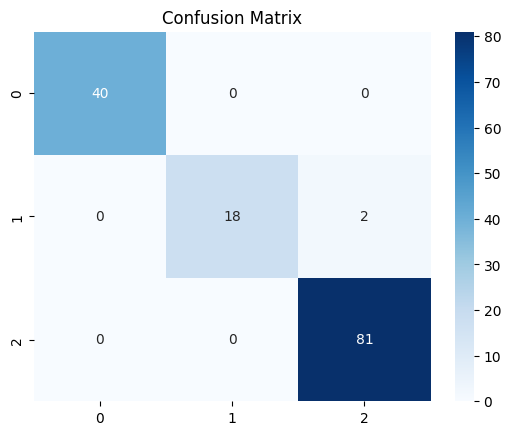

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Model Evaluation

The Random Forest classifier achieved an accuracy of 98.58%, outperforming Logistic Regression and Decision Tree models.

The model demonstrated excellent classification performance with a weighted precision, recall, and F1-score of 0.99.

Class 0 was perfectly classified with 100% precision and recall.

Class 1 achieved a recall of 90%, indicating a small number of misclassifications.

Class 2 achieved near-perfect classification performance with an F1-score of 0.99.

Overall, the model effectively predicts student social media addiction risk levels and can be used for real-time risk assessment applications.

In [21]:
# Save the Model
import joblib

joblib.dump(
    rf,
    "../models/social_media_addiction_model.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [22]:
# Verify:
import os

os.listdir("../models")

['social_media_addiction_model.pkl']

In [25]:

print("\n".join(X.columns))

Age
Gender
Academic_Level
Country
Avg_Daily_Usage_Hours
Most_Used_Platform
Affects_Academic_Performance
Sleep_Hours_Per_Night
Mental_Health_Score
Relationship_Status
Conflicts_Over_Social_Media
Usage_Sleep_Ratio
Wellbeing_Score
Conflict_Intensity
Academic_Risk


In [26]:
# Create Encoder Dictionary
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in df.select_dtypes(include="object"):
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [27]:
# Save Encoders
import joblib

joblib.dump(
    encoders,
    "../models/label_encoders.pkl"
)

print("Encoders saved successfully!")

Encoders saved successfully!


In [28]:
import os
os.listdir("../models")

['label_encoders.pkl', 'social_media_addiction_model.pkl']

In [29]:
# to get unique values for creating dropdown in streamlit
df = pd.read_csv("../data/processed/featured_data.csv")

print(df["Gender"].unique())
print(df["Academic_Level"].unique())
print(df["Country"].unique())
print(df["Most_Used_Platform"].unique())
print(df["Relationship_Status"].unique())

<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
<ArrowStringArray>
['Undergraduate', 'Graduate', 'High School']
Length: 3, dtype: str
<ArrowStringArray>
[ 'Bangladesh',       'India',         'USA',          'UK',      'Canada',
   'Australia',     'Germany',      'Brazil',       'Japan', 'South Korea',
 ...
     'Lebanon',        'Iraq',       'Yemen',       'Syria', 'Afghanistan',
    'Pakistan',       'Nepal',      'Bhutan',   'Sri Lanka',    'Maldives']
Length: 110, dtype: str
<ArrowStringArray>
['Instagram',   'Twitter',    'TikTok',   'YouTube',  'Facebook',  'LinkedIn',
  'Snapchat',      'LINE', 'KakaoTalk', 'VKontakte',  'WhatsApp',    'WeChat']
Length: 12, dtype: str
<ArrowStringArray>
['In Relationship', 'Single', 'Complicated']
Length: 3, dtype: str


In [34]:
import joblib

encoders = joblib.load("../models/label_encoders.pkl")

print(type(encoders))
print(encoders)

<class 'dict'>
{}


In [35]:
model = joblib.load("../models/social_media_addiction_model.pkl")

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [36]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_cols = [
    "Gender",
    "Academic_Level",
    "Country",
    "Most_Used_Platform",
    "Affects_Academic_Performance",
    "Relationship_Status",
    "Addiction_Risk"
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

print(encoders.keys())

dict_keys(['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Relationship_Status', 'Addiction_Risk'])


In [37]:
import joblib

joblib.dump(
    encoders,
    "../models/label_encoders.pkl"
)

print("Encoders Saved Successfully!")

Encoders Saved Successfully!


In [38]:
encoders = joblib.load("../models/label_encoders.pkl")

print(encoders.keys())

dict_keys(['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform', 'Affects_Academic_Performance', 'Relationship_Status', 'Addiction_Risk'])


In [39]:
print(X.shape)

(705, 15)


# Streamlit Deployment Model

A simplified Random Forest model was trained using only the most important numerical features to enable easy deployment through a Streamlit application.

In [40]:
X_simple = df[
    [
        "Age",
        "Avg_Daily_Usage_Hours",
        "Sleep_Hours_Per_Night",
        "Mental_Health_Score",
        "Conflicts_Over_Social_Media",
        "Usage_Sleep_Ratio",
        "Wellbeing_Score",
        "Conflict_Intensity"
    ]
]

y = df["Addiction_Risk"]

In [41]:
# Train-test split:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
# Train model:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_simple = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_simple.fit(X_train, y_train)

pred = rf_simple.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

ValueError: could not convert string to float: 'Low'

In [43]:
print(df["Addiction_Risk"].head())
print(df["Addiction_Risk"].dtype)

0    0
1    1
2    0
3    1
4    2
Name: Addiction_Risk, dtype: int64
int64


In [44]:
print(df["Conflict_Intensity"].dtype)
print(df["Conflict_Intensity"].unique())

str
<ArrowStringArray>
['Low', nan, 'Medium']
Length: 3, dtype: str


In [45]:
print(df["Conflict_Intensity"].isnull().sum())

4


In [46]:
df["Conflict_Intensity"] = df["Conflict_Intensity"].fillna("Low")

In [47]:
from sklearn.preprocessing import LabelEncoder

ci_encoder = LabelEncoder()

df["Conflict_Intensity"] = ci_encoder.fit_transform(
    df["Conflict_Intensity"]
)

In [48]:
print(df["Conflict_Intensity"].dtype)
print(df["Conflict_Intensity"].unique())

int64
[0 1]


In [49]:
X_simple = df[
    [
        "Age",
        "Avg_Daily_Usage_Hours",
        "Sleep_Hours_Per_Night",
        "Mental_Health_Score",
        "Conflicts_Over_Social_Media",
        "Usage_Sleep_Ratio",
        "Wellbeing_Score",
        "Conflict_Intensity"
    ]
]

print(X_simple.dtypes)

Age                              int64
Avg_Daily_Usage_Hours          float64
Sleep_Hours_Per_Night          float64
Mental_Health_Score              int64
Conflicts_Over_Social_Media      int64
Usage_Sleep_Ratio              float64
Wellbeing_Score                float64
Conflict_Intensity               int64
dtype: object


In [50]:
rf_simple.fit(X_train, y_train)

pred = rf_simple.predict(X_test)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, pred))

ValueError: could not convert string to float: 'Low'

In [51]:
print(X_simple.dtypes)

Age                              int64
Avg_Daily_Usage_Hours          float64
Sleep_Hours_Per_Night          float64
Mental_Health_Score              int64
Conflicts_Over_Social_Media      int64
Usage_Sleep_Ratio              float64
Wellbeing_Score                float64
Conflict_Intensity               int64
dtype: object


In [52]:
for col in X_simple.columns:
    if X_simple[col].dtype == "object" or str(X_simple[col].dtype) == "string":
        print("Problem Column:", col)
        print(X_simple[col].unique())

In [53]:
X_simple = df[
    [
        "Age",
        "Avg_Daily_Usage_Hours",
        "Sleep_Hours_Per_Night",
        "Mental_Health_Score",
        "Conflicts_Over_Social_Media",
        "Usage_Sleep_Ratio",
        "Wellbeing_Score",
        "Conflict_Intensity"
    ]
]

In [54]:
print(X_simple.dtypes)

Age                              int64
Avg_Daily_Usage_Hours          float64
Sleep_Hours_Per_Night          float64
Mental_Health_Score              int64
Conflicts_Over_Social_Media      int64
Usage_Sleep_Ratio              float64
Wellbeing_Score                float64
Conflict_Intensity               int64
dtype: object


In [55]:
y_simple = df["Addiction_Risk"]

print(y_simple.dtype)
print(y_simple.unique())

int64
[0 1 2]


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y_simple,
    test_size=0.2,
    random_state=42,
    stratify=y_simple
)

In [58]:
print(y_train.dtype)
print(y_train.unique())

int64
[2 1 0]


In [59]:
rf_simple = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_simple.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [60]:
print(y.dtype)
print(y.unique())
print(y_train.dtype)
print(y_train.unique())

int64
[0 1 2]
int64
[2 1 0]


In [61]:
from sklearn.metrics import accuracy_score

pred = rf_simple.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9787234042553191


In [62]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        40
           1       1.00      0.90      0.95        20
           2       0.96      1.00      0.98        81

    accuracy                           0.98       141
   macro avg       0.99      0.96      0.97       141
weighted avg       0.98      0.98      0.98       141



In [63]:
import joblib

joblib.dump(
    rf_simple,
    "../models/social_media_addiction_app_model.pkl"
)

print("Deployment model saved!")

Deployment model saved!


In [68]:
import os

print(os.listdir("../models"))

['label_encoders.pkl', 'social_media_addiction_app_model.pkl', 'social_media_addiction_model.pkl']


In [69]:
import joblib

model = joblib.load("../models/social_media_addiction_app_model.pkl")

print(type(model))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [70]:
# 1
from sklearn.metrics import accuracy_score

pred = rf_simple.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9787234042553191


In [71]:
# 2
import joblib

joblib.dump(
    rf_simple,
    "../models/social_media_addiction_app_model.pkl"
)

print("Deployment model saved!")

Deployment model saved!


In [72]:
# 3
import os

print(os.listdir("../models"))

['label_encoders.pkl', 'social_media_addiction_app_model.pkl', 'social_media_addiction_model.pkl']
